In [1]:
%matplotlib notebook

import numpy as np
import json
import math
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
#from numpy.random import seed 
#seed(2)
#tf.random.set_seed(9)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU,Dense, Dropout, Flatten, Input, BatchNormalization, Reshape, UpSampling1D, Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K 

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,Binarizer

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score,f1_score

In [2]:
fp_list = ['combine']

class Data():
    
    def __init__(self, fp, pos_neg):
        
        self.fp = fp
        self.pos_neg = pos_neg
        
        if self.pos_neg == 'pos':
            self.load_pos_data()
            self.shuffle()
            
        elif self.pos_neg == 'neg':
            self.load_neg_data()
            self.shuffle()
    

    def load_pos_data(self):
        with open('{}.json'.format(self.fp), 'r') as file:
            temp = json.load(file)
        positive_index = [i for i in range(len(temp['y'])) if temp['y'][i] == [1,0]]
        self.y = np.array([temp['y'][i] for i in positive_index])
        self.x = np.array([temp['x'][i] for i in positive_index])
        #self.x = self.__AddRandomBias2FP(self.x) 
        self.x = self.x.reshape(self.x.shape[0], self.x.shape[1],1)
        self.z = self.x.reshape(self.x.shape[0], self.x.shape[1])
        self.m = len(positive_index)
        self.n = self.x.shape[1]
        print('Shape x: {}'.format(self.x.shape))
        print('Shape y: {}'.format(self.y.shape))
    
    def load_neg_data(self):
        with open('{}.json'.format(self.fp), 'r') as file:
            temp = json.load(file)
        negative_index = [i for i in range(len(temp['y'])) if temp['y'][i] == [0,1]]
        self.y = np.array([temp['y'][i] for i in negative_index])
        self.x = np.array([temp['x'][i] for i in negative_index])
        #self.x = self.__AddRandomBias2FP(self.x) 
        self.x = self.x.reshape(self.x.shape[0], self.x.shape[1],1)
        self.z = self.x.reshape(self.x.shape[0], self.x.shape[1])
        self.m = len(negative_index)
        self.n = self.x.shape[1]
        print('Shape x: {}'.format(self.x.shape))
        print('Shape y: {}'.format(self.y.shape))
    
    def shuffle(self):
        temp_x = np.zeros(self.x.shape)
        index = list(range(self.m))
        np.random.shuffle(index)
        for x in range(self.m):
            value = int(index[int(x)])
            temp_x[x,:] = self.x[value,:]
        self.x = temp_x
                                  
    def __AddRandomBias2FP(self, BaseArray):
        ShapeArray = BaseArray.shape
        RandomBias = np.random.rand(ShapeArray[0], ShapeArray[1])
        NewArray = np.abs(BaseArray - np.true_divide(RandomBias, 1000))
        return NewArray

In [3]:
pos_data=Data(fp='combine', pos_neg='pos')
neg_data=Data(fp='combine', pos_neg='neg')

Shape x: (7002, 168, 1)
Shape y: (7002, 2)
Shape x: (9998, 168, 1)
Shape y: (9998, 2)


In [4]:
batch_size=7002
    #get real compounds
    #index = np.random.choice(range(pos_data.m), size=(batch_size), replace=False)
train_x_real = pos_data.x
train_y_real = np.zeros([batch_size,2])
train_y_real[:,0] = 1
    #d_loss_real = d.train_on_batch(train_x_real,train_y_real)

    #get decoys
index1 = np.random.choice(range(neg_data.m), size=(batch_size), replace=False)
train_x_decoy = neg_data.x[index1]
train_y_decoy = np.zeros([batch_size,2])
train_y_decoy[:,1] = 1
    #d_loss_decoy = d.train_on_batch(train_x_real,train_y_real)

    # d_loss = d_loss_real + d_loss_decoy
    # loss_d_epoch.append(d_loss[0])
X = np.concatenate((train_x_real, train_x_decoy))
y = np.zeros([2*batch_size,2])
y[0:(batch_size),0] = 1
y[(batch_size):,1] = 1
    
df_y = pd.DataFrame(y)
y_new = df_y.iloc[:,0]

In [5]:
cv = StratifiedKFold(n_splits=10)

In [6]:
def calc_precision(y_true, y_pred):
    true_pos = calc_true_positive(y_true, y_pred)
    return true_pos/np.sum(y_pred, axis=0)

def calc_recall(y_true, y_pred):
    true_pos = calc_true_positive(y_true, y_pred)
    return true_pos/np.sum(y_true, axis=0)

def calc_true_positive(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply(y_true,y_pred), axis=0)
    else:
        return tf.reduce_sum(y_true*y_pred)

def calc_true_negative(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_true),(1-y_pred)), axis=0)
    else:
        return tf.reduce_sum((1-y_true)*(1-y_pred))

def calc_false_positive(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_true),(y_pred)), axis=0)
    else:
        return tf.reduce_sum((1-y_true)*y_pred)

def calc_false_negative(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_pred),y_true), axis=0)
    else:
        return tf.reduce_sum(y_true*(1-y_pred))

In [ ]:
mean_fpr = np.linspace(0, 1, 100)
tprs=[]
tprs_all=[]
fprs=[]
aucs=[]
accs=[]
f1s=[]
TPs=[]
TNs=[]
FPs=[]
FNs=[]
precisions=[]
recalls=[]

for train,test in cv.split(X,y_new):


    model = Sequential()
    model.add(Conv1D(8, kernel_size=3,
                     strides=1,
                     activation='relu',
                     padding='valid',
                     input_shape=[168,1],
                     kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(16, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(16, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    #model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    #model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    #model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(2, activation='softmax', kernel_regularizer=regularizers.l2(0.01)))

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=keras.optimizers.Adam(lr=0.00045),
                  metrics=['accuracy'])




    model.fit(X[train],y[train],
                 batch_size=batch_size,
                 epochs=80,
                 verbose=1,
                 validation_data=(X[test],y[test]))
              
    pred_prob = model.predict(X[test])[:,0]
    pred = model.predict(X[test])[:,0]
    y_pred = np.round(pred)
    print(y_pred)
    print(pred_prob)
    fpr, tpr, thresholds = roc_curve(y_new[test],pred_prob)
    roc_auc = auc(fpr,tpr)
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs_all.append(interp_tpr)

    acc = accuracy_score(y_new[test], y_pred)
    f1 = f1_score(y_new[test], y_pred)
    accs.append(acc)
    f1s.append(f1)
    
    TP=calc_true_positive(y_new[test], y_pred)
    TN=calc_true_negative(y_new[test], y_pred)
    FP=calc_false_positive(y_new[test], y_pred)
    FN=calc_false_negative(y_new[test], y_pred)
    TPs.append(TP)
    TNs.append(TN)
    FPs.append(FP)
    FNs.append(FN)

    prec = calc_precision(y_new[test], y_pred)
    recall=calc_recall(y_new[test],y_pred)

    precisions.append(prec)
    recalls.append(recall)
    
    del model
    K.clear_session()


Epoch 1/80
2/2 [==============================] - 3s 2s/step - loss: 8.1836 - accuracy: 0.5006 - val_loss: 8.0473 - val_accuracy: 0.5004
Epoch 2/80
2/2 [==============================] - 2s 904ms/step - loss: 8.0080 - accuracy: 0.5146 - val_loss: 7.8744 - val_accuracy: 0.5004
Epoch 3/80
2/2 [==============================] - 2s 883ms/step - loss: 7.8357 - accuracy: 0.5236 - val_loss: 7.7046 - val_accuracy: 0.5004
Epoch 4/80
2/2 [==============================] - 2s 895ms/step - loss: 7.6661 - accuracy: 0.5330 - val_loss: 7.5378 - val_accuracy: 0.5004
Epoch 5/80
2/2 [==============================] - 2s 918ms/step - loss: 7.4997 - accuracy: 0.5424 - val_loss: 7.3741 - val_accuracy: 0.5004
Epoch 6/80
2/2 [==============================] - 2s 837ms/step - loss: 7.3368 - accuracy: 0.5384 - val_loss: 7.2136 - val_accuracy: 0.5004
Epoch 7/80
2/2 [==============================] - 2s 866ms/step - loss: 7.1769 - accuracy: 0.5320 - val_loss: 7.0562 - val_accuracy: 0.5004
Epoch 8/80
2/2 [=======

2/2 [==============================] - 2s 1s/step - loss: 2.3478 - accuracy: 0.6104 - val_loss: 2.3606 - val_accuracy: 0.4996
Epoch 61/80
2/2 [==============================] - 2s 800ms/step - loss: 2.3032 - accuracy: 0.6090 - val_loss: 2.3267 - val_accuracy: 0.5004
Epoch 62/80
2/2 [==============================] - 1s 589ms/step - loss: 2.2622 - accuracy: 0.6007 - val_loss: 2.2696 - val_accuracy: 0.5032
Epoch 63/80
2/2 [==============================] - 1s 676ms/step - loss: 2.2191 - accuracy: 0.6143 - val_loss: 2.2281 - val_accuracy: 0.5061
Epoch 64/80
2/2 [==============================] - 2s 1s/step - loss: 2.1800 - accuracy: 0.6110 - val_loss: 2.1999 - val_accuracy: 0.5004
Epoch 65/80
2/2 [==============================] - 2s 1s/step - loss: 2.1400 - accuracy: 0.6120 - val_loss: 2.1516 - val_accuracy: 0.5082
Epoch 66/80
2/2 [==============================] - 2s 1s/step - loss: 2.1018 - accuracy: 0.6187 - val_loss: 2.1098 - val_accuracy: 0.5118
Epoch 67/80
2/2 [====================

Epoch 37/80
2/2 [==============================] - 2s 1s/step - loss: 3.7260 - accuracy: 0.5884 - val_loss: 3.6859 - val_accuracy: 0.5004
Epoch 38/80
2/2 [==============================] - 2s 1s/step - loss: 3.6479 - accuracy: 0.5968 - val_loss: 3.6085 - val_accuracy: 0.4996
Epoch 39/80
2/2 [==============================] - 2s 1s/step - loss: 3.5706 - accuracy: 0.6001 - val_loss: 3.5335 - val_accuracy: 0.4989
Epoch 40/80
2/2 [==============================] - 2s 1s/step - loss: 3.4985 - accuracy: 0.5945 - val_loss: 3.4621 - val_accuracy: 0.4989
Epoch 41/80
2/2 [==============================] - 2s 1s/step - loss: 3.4259 - accuracy: 0.5910 - val_loss: 3.3926 - val_accuracy: 0.4989
Epoch 42/80
2/2 [==============================] - 2s 1s/step - loss: 3.3554 - accuracy: 0.5960 - val_loss: 3.3212 - val_accuracy: 0.4982
Epoch 43/80
2/2 [==============================] - 2s 1s/step - loss: 3.2864 - accuracy: 0.5974 - val_loss: 3.2522 - val_accuracy: 0.4918
Epoch 44/80
2/2 [=================

2/2 [==============================] - 2s 1s/step - loss: 6.0069 - accuracy: 0.5643 - val_loss: 5.9059 - val_accuracy: 0.4996
Epoch 16/80
2/2 [==============================] - 2s 1s/step - loss: 5.8752 - accuracy: 0.5555 - val_loss: 5.7766 - val_accuracy: 0.4996
Epoch 17/80
2/2 [==============================] - 2s 1s/step - loss: 5.7463 - accuracy: 0.5643 - val_loss: 5.6502 - val_accuracy: 0.4996
Epoch 18/80
2/2 [==============================] - 2s 1s/step - loss: 5.6203 - accuracy: 0.5655 - val_loss: 5.5267 - val_accuracy: 0.4996
Epoch 19/80
2/2 [==============================] - 2s 1s/step - loss: 5.4972 - accuracy: 0.5680 - val_loss: 5.4061 - val_accuracy: 0.4996
Epoch 20/80
2/2 [==============================] - 2s 1s/step - loss: 5.3770 - accuracy: 0.5722 - val_loss: 5.2884 - val_accuracy: 0.4996
Epoch 21/80
2/2 [==============================] - 2s 1s/step - loss: 5.2597 - accuracy: 0.5800 - val_loss: 5.1734 - val_accuracy: 0.4996
Epoch 22/80
2/2 [=============================

2/2 [==============================] - 2s 926ms/step - loss: 1.8538 - accuracy: 0.6163 - val_loss: 1.8392 - val_accuracy: 0.5889
Epoch 74/80
2/2 [==============================] - 2s 905ms/step - loss: 1.8240 - accuracy: 0.6154 - val_loss: 1.8092 - val_accuracy: 0.5867
Epoch 75/80
2/2 [==============================] - 2s 935ms/step - loss: 1.7931 - accuracy: 0.6203 - val_loss: 1.7767 - val_accuracy: 0.5953
Epoch 76/80
2/2 [==============================] - 2s 1s/step - loss: 1.7622 - accuracy: 0.6210 - val_loss: 1.7462 - val_accuracy: 0.6003
Epoch 77/80
2/2 [==============================] - 2s 871ms/step - loss: 1.7351 - accuracy: 0.6176 - val_loss: 1.7209 - val_accuracy: 0.6003
Epoch 78/80
2/2 [==============================] - 2s 967ms/step - loss: 1.7074 - accuracy: 0.6209 - val_loss: 1.6895 - val_accuracy: 0.6067
Epoch 79/80
2/2 [==============================] - 2s 907ms/step - loss: 1.6774 - accuracy: 0.6252 - val_loss: 1.6653 - val_accuracy: 0.6060
Epoch 80/80
2/2 [===========

...

2/2 [==============================] - 2s 758ms/step - loss: 3.5186 - accuracy: 0.5965 - val_loss: 3.4669 - val_accuracy: 0.5000
Epoch 41/80
2/2 [==============================] - 2s 918ms/step - loss: 3.4465 - accuracy: 0.5912 - val_loss: 3.3962 - val_accuracy: 0.5000
Epoch 42/80
2/2 [==============================] - 2s 940ms/step - loss: 3.3758 - accuracy: 0.5961 - val_loss: 3.3276 - val_accuracy: 0.5000
Epoch 43/80
2/2 [==============================] - 2s 986ms/step - loss: 3.3071 - accuracy: 0.5943 - val_loss: 3.2607 - val_accuracy: 0.5000
Epoch 44/80
2/2 [==============================] - 2s 835ms/step - loss: 3.2397 - accuracy: 0.5904 - val_loss: 3.1954 - val_accuracy: 0.5000
Epoch 45/80
2/2 [==============================] - 2s 894ms/step - loss: 3.1740 - accuracy: 0.5982 - val_loss: 3.1311 - val_accuracy: 0.5000
Epoch 46/80
2/2 [==============================] - 2s 842ms/step - loss: 3.1104 - accuracy: 0.5942 - val_loss: 3.0686 - val_accuracy: 0.4986
Epoch 47/80
2/2 [========

Epoch 18/80
2/2 [==============================] - 2s 896ms/step - loss: 5.6376 - accuracy: 0.5809 - val_loss: 5.5497 - val_accuracy: 0.5000
Epoch 19/80
2/2 [==============================] - 2s 916ms/step - loss: 5.5148 - accuracy: 0.5751 - val_loss: 5.4297 - val_accuracy: 0.5000
Epoch 20/80
2/2 [==============================] - 2s 890ms/step - loss: 5.3939 - accuracy: 0.5831 - val_loss: 5.3124 - val_accuracy: 0.5000
Epoch 21/80
2/2 [==============================] - 2s 793ms/step - loss: 5.2762 - accuracy: 0.5850 - val_loss: 5.1981 - val_accuracy: 0.5000
Epoch 22/80
2/2 [==============================] - 2s 996ms/step - loss: 5.1604 - accuracy: 0.5927 - val_loss: 5.0866 - val_accuracy: 0.5000
Epoch 23/80
2/2 [==============================] - 2s 919ms/step - loss: 5.0483 - accuracy: 0.5931 - val_loss: 4.9779 - val_accuracy: 0.5000
Epoch 24/80
2/2 [==============================] - 2s 866ms/step - loss: 4.9390 - accuracy: 0.5911 - val_loss: 4.8717 - val_accuracy: 0.5000
Epoch 25/80
2

2/2 [==============================] - 2s 872ms/step - loss: 1.7734 - accuracy: 0.6304 - val_loss: 1.7545 - val_accuracy: 0.6164
Epoch 77/80
2/2 [==============================] - 2s 813ms/step - loss: 1.7441 - accuracy: 0.6284 - val_loss: 1.7279 - val_accuracy: 0.6143
Epoch 78/80
2/2 [==============================] - 2s 937ms/step - loss: 1.7176 - accuracy: 0.6239 - val_loss: 1.6947 - val_accuracy: 0.6271
Epoch 79/80
2/2 [==============================] - 2s 972ms/step - loss: 1.6875 - accuracy: 0.6353 - val_loss: 1.6710 - val_accuracy: 0.6193
Epoch 80/80
2/2 [==============================] - 2s 914ms/step - loss: 1.6627 - accuracy: 0.6306 - val_loss: 1.6466 - val_accuracy: 0.6164
[1. 1. 1. ... 1. 1. 1.]
[0.71621    0.52061087 0.7159408  ... 0.58895695 0.6978632  0.604442  ]
Epoch 1/80
2/2 [==============================] - 4s 2s/step - loss: 8.2114 - accuracy: 0.4963 - val_loss: 8.0726 - val_accuracy: 0.5000
Epoch 2/80
2/2 [==============================] - 2s 931ms/step - loss: 8.

2/2 [==============================] - 1s 653ms/step - loss: 2.7075 - accuracy: 0.5925 - val_loss: 2.6728 - val_accuracy: 0.5000
Epoch 54/80
2/2 [==============================] - 1s 662ms/step - loss: 2.6549 - accuracy: 0.5998 - val_loss: 2.6218 - val_accuracy: 0.4986
Epoch 55/80
2/2 [==============================] - 1s 655ms/step - loss: 2.6042 - accuracy: 0.5924 - val_loss: 2.5731 - val_accuracy: 0.4979
Epoch 56/80
2/2 [==============================] - 1s 629ms/step - loss: 2.5543 - accuracy: 0.5953 - val_loss: 2.5254 - val_accuracy: 0.4971
Epoch 57/80
2/2 [==============================] - 1s 584ms/step - loss: 2.5061 - accuracy: 0.5974 - val_loss: 2.4763 - val_accuracy: 0.4957
Epoch 58/80
2/2 [==============================] - 1s 613ms/step - loss: 2.4590 - accuracy: 0.5977 - val_loss: 2.4290 - val_accuracy: 0.5007
Epoch 59/80
2/2 [==============================] - 1s 541ms/step - loss: 2.4127 - accuracy: 0.5969 - val_loss: 2.3850 - val_accuracy: 0.4971
Epoch 60/80
2/2 [========

2/2 [==============================] - 1s 617ms/step - loss: 4.3275 - accuracy: 0.5978 - val_loss: 4.2811 - val_accuracy: 0.5000
Epoch 31/80
2/2 [==============================] - 1s 586ms/step - loss: 4.2352 - accuracy: 0.5954 - val_loss: 4.1889 - val_accuracy: 0.5000
Epoch 32/80
2/2 [==============================] - 1s 589ms/step - loss: 4.1444 - accuracy: 0.5997 - val_loss: 4.1020 - val_accuracy: 0.5000
Epoch 33/80
2/2 [==============================] - 1s 555ms/step - loss: 4.0575 - accuracy: 0.5935 - val_loss: 4.0186 - val_accuracy: 0.5000
Epoch 34/80
2/2 [==============================] - 1s 603ms/step - loss: 3.9717 - accuracy: 0.5896 - val_loss: 3.9347 - val_accuracy: 0.5000
Epoch 35/80
2/2 [==============================] - 1s 596ms/step - loss: 3.8869 - accuracy: 0.6007 - val_loss: 3.8468 - val_accuracy: 0.5014
Epoch 36/80
2/2 [==============================] - 1s 629ms/step - loss: 3.8057 - accuracy: 0.5989 - val_loss: 3.7702 - val_accuracy: 0.5007
Epoch 37/80
2/2 [========

<IPython.core.display.Javascript object>


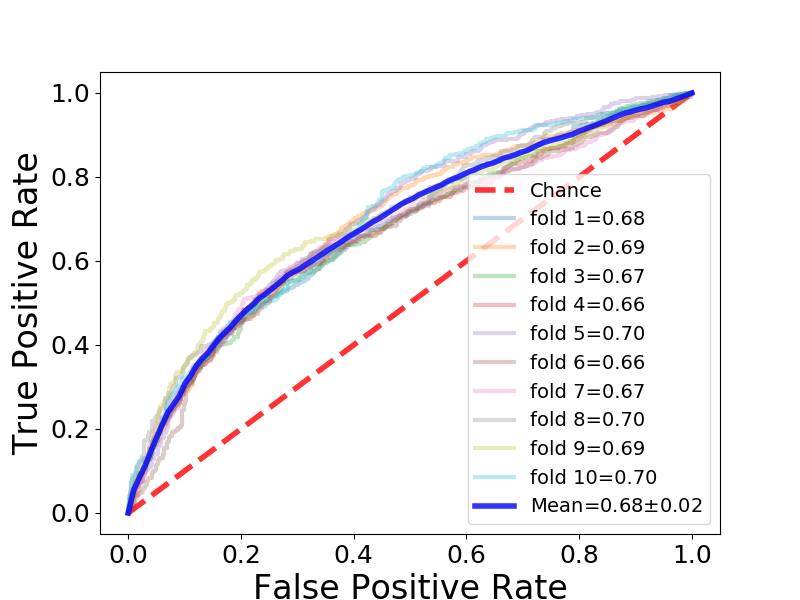

In [8]:
fig, ax = plt.subplots(figsize = (8,6))

ax.plot([0, 1], [0, 1], linestyle='--', color='r',
        label='Chance', alpha=.8, linewidth = 4)

for j in range(10):
    ax.plot(fprs[j], tprs[j], label='fold {0}={1:0.2f}'.format(j+1, aucs[j]), alpha=0.3, linewidth = 3)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean(tprs_all, axis=0)
mean_tpr[-1] = 1.0
mean_auc_svm = auc(mean_fpr, mean_tpr)
std_auc_svm = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean=%0.2f$\pm$%0.2f' % (mean_auc_svm, std_auc_svm),
        alpha=.8, linewidth = 4)

std_tpr = np.std(tprs_all, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
#ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
#                label=r'$\pm$ 1 std. dev.')
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])

ax.legend(loc="lower right")

plt.xlabel('False Positive Rate', fontsize=24)
plt.ylabel('True Positive Rate', fontsize=24)
plt.legend(loc="lower right", prop={"size":14})
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('maccs_D_vggnet13.pdf',dpi=600)
plt.show()